# KOICA HR 규정 TF-IDF 키워드 분석

- 대상: `category == hr` 10개 규정 (인사·보수·복무·국외여비·정관 등)
- 토크나이저: `koica_search`의 조사 제거 + STOPWORDS 규칙 재사용 (TF 보존을 위해 dedup만 제거)
- 출력: 규정별 상위 키워드 표, 상위 키워드 막대그래프 그리드, HR 전체 워드클라우드

In [1]:
# 1. 환경 셋업
import sys, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

from load_data import load_hr_articles, tokenize_body, docs_by_source

KOREAN_FONT = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
rcParams['font.family'] = 'AppleGothic'
rcParams['axes.unicode_minus'] = False

OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

In [2]:
# 2. 데이터 로드
articles = load_hr_articles()
print('총 조문:', len(articles), '/ 규정:', articles['source'].nunique())
articles.groupby('source').size().sort_values(ascending=False)

총 조문: 381 / 규정: 10


source
인사규정 시행세칙     69
복무규정          66
인사규정          54
보수규정          44
한국국제협력단 정관    41
국외여비규정        30
근무성적 평가지침     30
직제규정          29
업무인계인수지침      11
직제규정 시행세칙      7
dtype: int64

In [3]:
# 3. 문서 단위 결정 — 기본은 규정 단위(A). 조문 단위로 보고 싶으면 USE_ARTICLE_LEVEL=True
USE_ARTICLE_LEVEL = False

if USE_ARTICLE_LEVEL:
    docs = articles.copy()
    docs['doc_id'] = docs['source'] + ' ' + docs['article']
else:
    docs = docs_by_source(articles).rename(columns={'source': 'doc_id'})

print('문서 수:', len(docs))
docs.head()

문서 수: 10


,doc_id,body,n_articles
0,국외여비규정,이 규정은 한국국제협력단 임직원이 공무로 외국에 여행할 때에 지급하는 여비에 관한 ...,30
1,근무성적 평가지침,"이 지침은 한국국제협력단(이하 ""협력단""이라 한다) 직원의 업적평정과 역량평정에 관...",30
2,보수규정,"이 규정은 한국국제협력단(이하 ""협력단""이라 한다) 임직원에게 개인의 성과와 공헌도...",44
3,복무규정,이 규정은 한국국제협력단 직원의 복무에 관한 사항을 규정함을 목적으로 한다.\n한국...,66
4,업무인계인수지침,이 지침은 한국국제협력단 임직원의 신분상 또는 업무상의 변동이 발생할 경우\n4. ...,11


In [4]:
# 4. 토큰화 — 도메인 불용어 추가
DOMAIN_STOPWORDS = {
    '협력단', '이사장', '다음', '각호', '경우', '대하여', '관하여', '관한', '대한',
    '있다', '한다', '하는', '따라', '따른', '관련', '이상', '이하', '하여', '하여야',
    '본다', '본조', '제1항', '제2항', '제3항', '해당', '아니', '아니한다', '아니하다',
    '그러하지', '같다', '이를', '이에', '또는', '및', '등의', '및의'
}

docs['tokens'] = docs['body'].apply(lambda t: tokenize_body(t, DOMAIN_STOPWORDS))
docs['n_tokens'] = docs['tokens'].apply(len)
docs[['doc_id', 'n_tokens']].sort_values('n_tokens', ascending=False)

,doc_id,n_tokens
6,인사규정 시행세칙,2154
3,복무규정,2012
5,인사규정,1834
2,보수규정,1086
7,한국국제협력단 정관,1036
0,국외여비규정,924
4,업무인계인수지침,850
1,근무성적 평가지침,819
8,직제규정,594
9,직제규정 시행세칙,247


In [5]:
# 5. TF-IDF 계산
corpus = docs['tokens'].apply(' '.join).tolist()
vec = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=lambda x: x,
    lowercase=False,
    token_pattern=None,
    min_df=2,
    max_df=0.9,
)
X = vec.fit_transform(corpus)
vocab = np.array(vec.get_feature_names_out())
print('어휘 크기:', len(vocab), '/ 행렬:', X.shape)

어휘 크기: 1069 / 행렬: (10, 1069)


In [6]:
# 6. 규정별 상위 키워드 (TOP 15)
TOP_N = 15
rows = []
for i, doc_id in enumerate(docs['doc_id']):
    row = X[i].toarray().ravel()
    top_idx = row.argsort()[::-1][:TOP_N]
    for rank, j in enumerate(top_idx, 1):
        if row[j] == 0:
            break
        rows.append({'source': doc_id, 'rank': rank, 'keyword': vocab[j], 'tfidf': float(row[j])})

top_kw = pd.DataFrame(rows)
top_kw.to_csv(OUT / 'hr_top_keywords.csv', index=False)
top_kw.pivot(index='rank', columns='source', values='keyword')

source,국외여비규정,근무성적 평가지침,보수규정,복무규정,업무인계인수지침,인사규정,인사규정 시행세칙,직제규정,직제규정 시행세칙,한국국제협력단 정관
rank,,,,,,,,,,
1,지급한다,업적평정,연봉,직원,지침,직원,직원,상임이사,둔다,이사회
2,외국,평정,지급한다,휴가,시행한다,위원회,위원회,둔다,본사,사업
3,금액,평가,직원,1일,작성,휴직기간,징계,담당하고,조정,외교부장관
4,가족,직원,징계처분,임신,서류,징계,2년,집행,업무,운영
5,전액,점수,지급하지,기간,업무,위원장,해당하,정원,업무분장,사람
6,허가,산출한다,받은,때에,결재,말한다,채용,등을,별표,의결
7,지역,역량평정,보수,자녀,사유,해당하,기간,조직,정원,감사
8,따라서,편람,성과연봉,근로자,서식,기간,받은,직무,일반직,호의
9,본인,성과연봉,기간,된다,기준일,이내,최근,경영전략본부,직제규정,재산


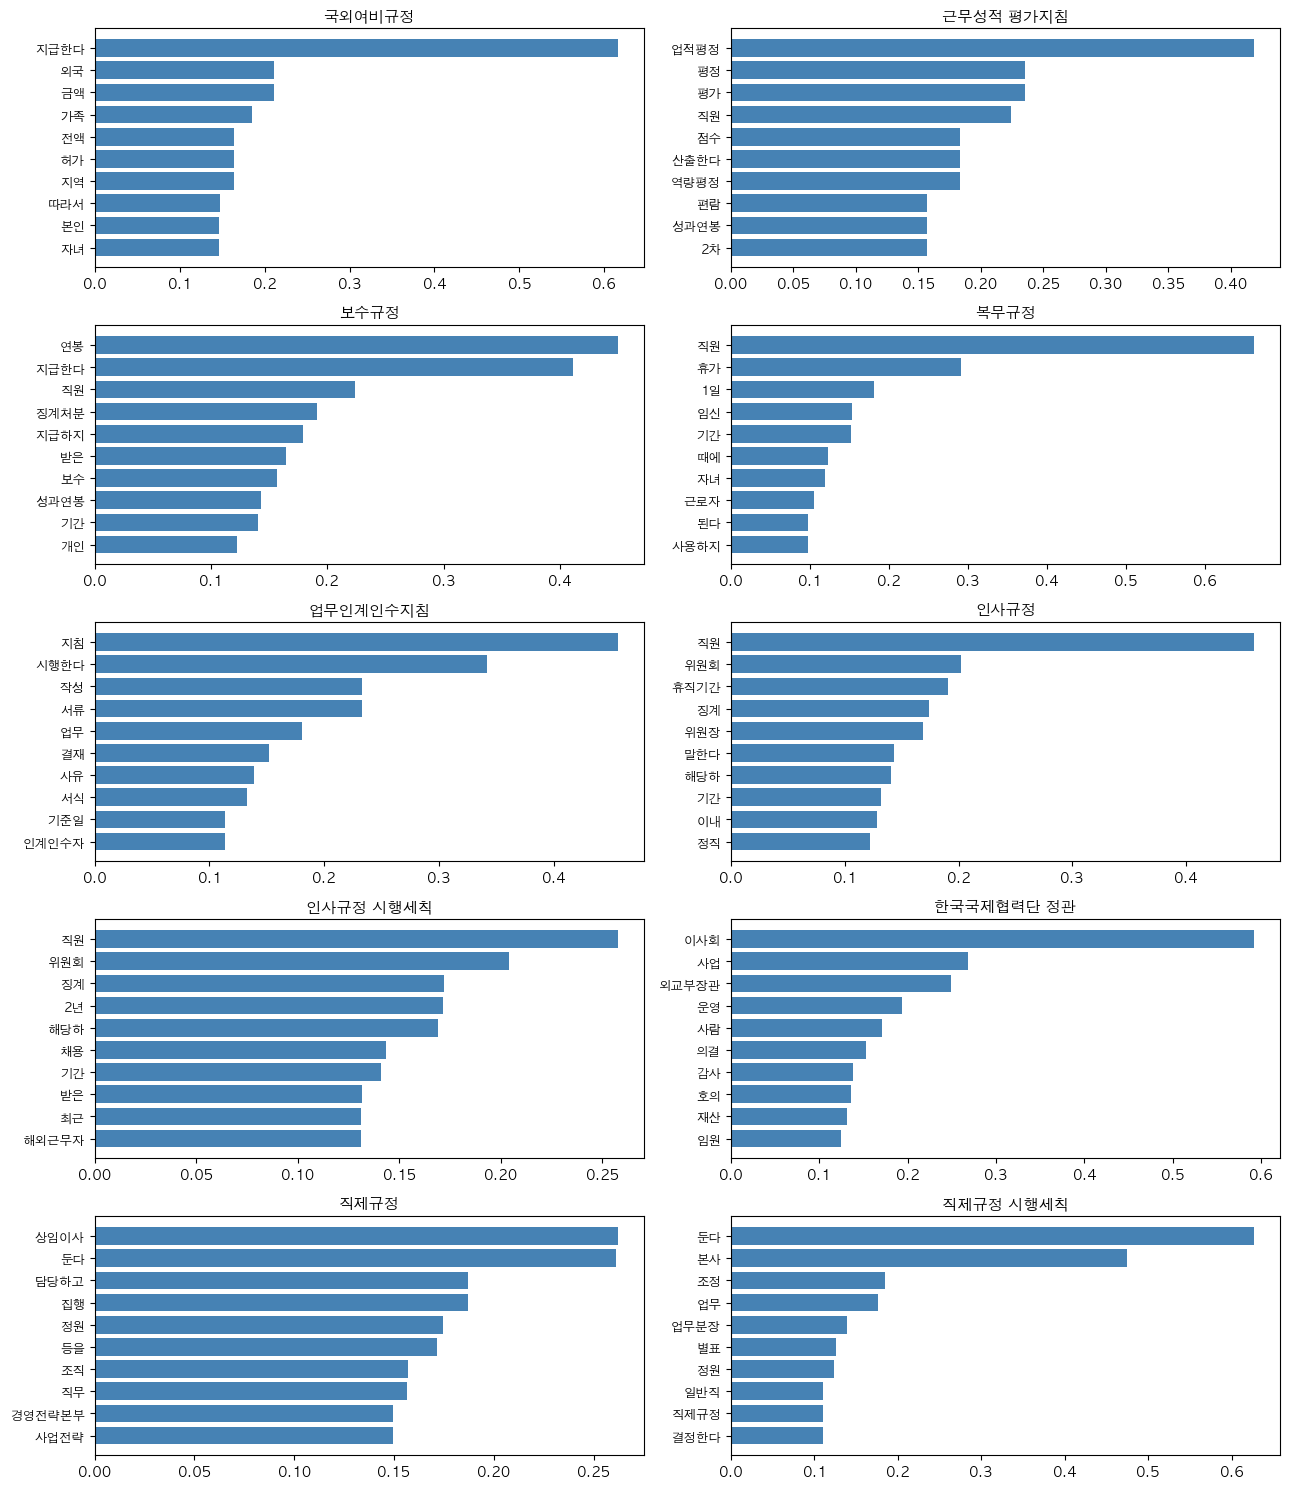

In [7]:
# 7. 막대그래프 — 규정별 상위 10개
BAR_N = 10
sources = docs['doc_id'].tolist()
ncol = 2
nrow = math.ceil(len(sources) / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3 * nrow))
axes = axes.flatten()
for ax, src in zip(axes, sources):
    sub = top_kw[top_kw['source'] == src].head(BAR_N).iloc[::-1]
    ax.barh(sub['keyword'], sub['tfidf'], color='steelblue')
    ax.set_title(src, fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
for ax in axes[len(sources):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'hr_top_keywords_bars.png', dpi=140, bbox_inches='tight')
plt.show()

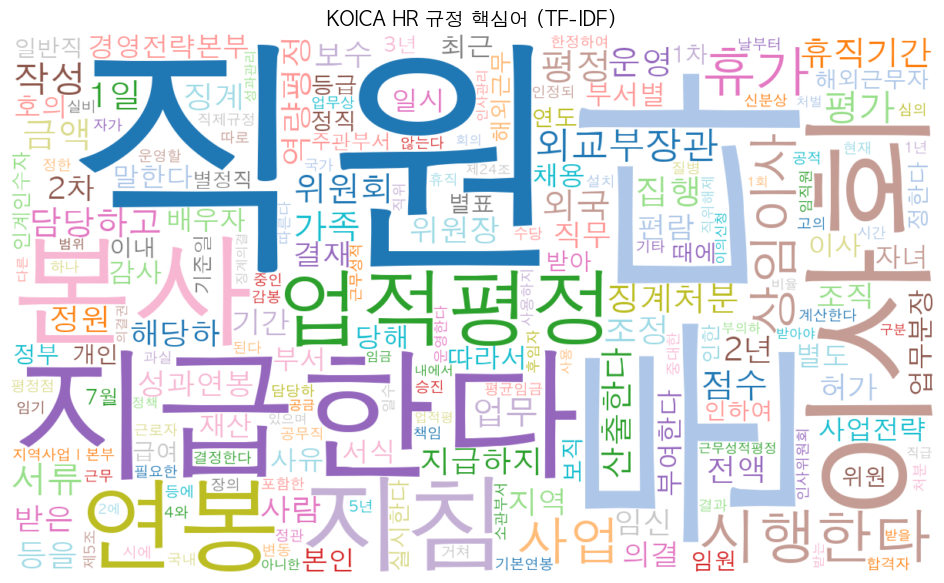

In [8]:
# 8. 워드클라우드 — HR 전체에서 문서별 TF-IDF 최대값으로 어휘 가중
weights = {}
X_dense = X.toarray()
max_score = X_dense.max(axis=0)
for term, w in zip(vocab, max_score):
    if w > 0:
        weights[term] = float(w)

wc = WordCloud(
    font_path=KOREAN_FONT,
    width=1200, height=700,
    background_color='white',
    max_words=200,
    colormap='tab20',
).generate_from_frequencies(weights)

plt.figure(figsize=(13, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('KOICA HR 규정 핵심어 (TF-IDF)', fontsize=14)
wc.to_file(str(OUT / 'hr_wordcloud.png'))
plt.show()

In [9]:
# 9. 검증 — koica_search.compute_idf와 sklearn IDF 순위 상관 (스피어만)
from koica_search import compute_idf, load_index
all_articles_obj = [a for a in load_index() if a.category == 'hr']
sample_terms = list(vocab[:200])
ks_idf = compute_idf(sample_terms, all_articles_obj)
sklearn_idf = dict(zip(vec.get_feature_names_out(), vec.idf_))
df_cmp = pd.DataFrame({
    'term': sample_terms,
    'koica_idf': [ks_idf[t] for t in sample_terms],
    'sklearn_idf': [sklearn_idf[t] for t in sample_terms],
})
rho = df_cmp[['koica_idf', 'sklearn_idf']].corr(method='spearman').iloc[0, 1]
print(f'스피어만 순위 상관: {rho:.3f}')
df_cmp.head(10)

스피어만 순위 상관: 0.628


,term,koica_idf,sklearn_idf
0,---,5.153661,1.606136
1,10년,5.846808,2.299283
2,10일,4.865979,2.011601
3,10일까지,5.846808,2.299283
4,12월,4.460514,1.318454
5,14일,5.559126,2.299283
6,15일,5.153661,1.788457
7,180일,5.846808,2.299283
8,1개월,4.642836,1.606136
9,1과,5.559126,2.011601
